In [1]:
# import wandb
# wandb.login(key='REDACTED_WANDB_API_KEY') 

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tahmidulkashfi15 (tahmidulkashfi15-international-islamic-university-chittagong) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [1]:
#!/usr/bin/env python3
"""
Complete Training and Testing Script for Lung Cancer Classification
Using Concatenated CNN Attention Model

Author: Based on research paper implementation
Dataset: IQ-OTH/NCCD Lung Cancer Dataset
Architecture: Concatenated CNN Attention Model (CCAL)
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
from tqdm import tqdm
import time
import json
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")


# ─────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────
class LungCancerDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = ['Bengin cases', 'Malignant cases', 'Normal cases']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                for img_file in os.listdir(class_dir):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')):
                        self.images.append(os.path.join(class_dir, img_file))
                        self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ─────────────────────────────────────────────
# Wrapper to apply different transforms on subsets
# ─────────────────────────────────────────────
class TransformSubset(Dataset):
    """Wraps a Subset and applies a given transform."""
    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ─────────────────────────────────────────────
# Model Components
# ─────────────────────────────────────────────
class CNNModel1(nn.Module):
    """CNN Model-1: Deeper architecture for hierarchical patterns"""
    def __init__(self):
        super(CNNModel1, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = torch.relu(self.conv4(x))
        x = torch.relu(self.conv5(x))
        x = self.global_max_pool(x)
        x = x.view(x.size(0), -1)
        return x


class CNNModel2(nn.Module):
    """CNN Model-2: Simpler architecture for broader features"""
    def __init__(self):
        super(CNNModel2, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.global_max_pool(x)
        x = x.view(x.size(0), -1)
        return x


class MultiHeadAttentionBlock(nn.Module):
    """Multi-Head Attention block with 4 heads"""
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super(MultiHeadAttentionBlock, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, attn_weights = self.multihead_attn(x, x, x)
        x = self.layer_norm(x + self.dropout(attn_output))
        return x, attn_weights


class MLPBlock(nn.Module):
    """MLP Block with Global Average Pooling and GELU activation"""
    def __init__(self, input_dim, hidden_dim=256, num_classes=3, dropout=0.1):
        super(MLPBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.batch_norm1     = nn.BatchNorm1d(input_dim)
        self.dense1          = nn.Linear(input_dim, hidden_dim)
        self.batch_norm2     = nn.BatchNorm1d(hidden_dim)
        self.dense2          = nn.Linear(hidden_dim, num_classes)
        self.dropout         = nn.Dropout(dropout)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_avg_pool(x)
        x = x.squeeze(-1)
        x = self.batch_norm1(x)
        x = torch.nn.functional.gelu(self.dense1(x))
        x = self.dropout(x)
        x = self.batch_norm2(x)
        x = self.dense2(x)
        return x


class ConcatenatedCNNAttentionModel(nn.Module):
    """Complete CCAL Model Implementation"""
    def __init__(self, num_classes=3, num_heads=4, hidden_dim=256, dropout=0.1):
        super(ConcatenatedCNNAttentionModel, self).__init__()
        self.cnn_model1 = CNNModel1()
        self.cnn_model2 = CNNModel2()

        self.concat_dim        = 256 + 32   # 288 total features
        self.seq_length        = 8
        self.feature_projection = nn.Linear(self.concat_dim, self.seq_length * self.concat_dim)

        self.mha_layer1 = MultiHeadAttentionBlock(embed_dim=self.concat_dim,
                                                   num_heads=num_heads,
                                                   dropout=dropout)
        self.mha_layer2 = MultiHeadAttentionBlock(embed_dim=self.concat_dim,
                                                   num_heads=num_heads,
                                                   dropout=dropout)
        self.mlp_block  = MLPBlock(input_dim=self.concat_dim,
                                   hidden_dim=hidden_dim,
                                   num_classes=num_classes,
                                   dropout=dropout)

    def forward(self, x):
        features1       = self.cnn_model1(x)
        features2       = self.cnn_model2(x)
        concat_features = torch.cat([features1, features2], dim=1)

        projected_features = self.feature_projection(concat_features)
        batch_size         = projected_features.size(0)
        sequence_features  = projected_features.view(batch_size, self.seq_length, self.concat_dim)

        attention_output1, _ = self.mha_layer1(sequence_features)
        attention_output2, _ = self.mha_layer2(attention_output1)

        output = self.mlp_block(attention_output2)
        return output


# ─────────────────────────────────────────────
# Transforms
# ─────────────────────────────────────────────
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, test_transform


# ─────────────────────────────────────────────
# Data Loaders  (leakage fixed)
# ─────────────────────────────────────────────
def create_data_loaders(data_dir, batch_size=32, train_split=0.8, num_workers=4):
    """
    Fix: load the dataset ONCE with no transform, split indices ONCE,
    then wrap each subset with its own transform via TransformSubset.
    This guarantees zero overlap between train and test images.
    """
    train_transform, test_transform = get_transforms()

    # Single dataset, no transform yet
    full_dataset = LungCancerDataset(data_dir, transform=None)

    dataset_size = len(full_dataset)
    train_size   = int(train_split * dataset_size)
    test_size    = dataset_size - train_size

    # ONE split — indices never overlap
    train_subset, test_subset = random_split(
        full_dataset,
        [train_size, test_size],
        generator=torch.Generator().manual_seed(42)   # reproducible
    )

    # Attach the correct transform to each split
    train_dataset = TransformSubset(train_subset, transform=train_transform)
    test_dataset  = TransformSubset(test_subset,  transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)

    logger.info(f"Total   samples : {dataset_size}")
    logger.info(f"Training samples: {len(train_dataset)}")
    logger.info(f"Testing  samples: {len(test_dataset)}")

    return train_loader, test_loader

def train_epoch(model, train_loader, criterion, optimizer, device, ema=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(train_loader, desc="Training")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # ── Update EMA weights after every step ──
        if ema is not None:
            ema.update(model)

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total   += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        pbar.set_postfix({
            'Loss': f"{running_loss / (batch_idx + 1):.4f}",
            'Acc' : f"{100. * correct / total:.2f}%"
        })

    return running_loss / len(train_loader), 100. * correct / total


def test_model(model, test_loader, criterion, device, ema=None):
    # ── Use EMA weights for evaluation ──
    if ema is not None:
        ema.apply_shadow(model)

    model.eval()
    test_loss       = 0.0
    correct         = 0
    total           = 0
    all_targets     = []
    all_predictions = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)

            test_loss   += loss.item()
            _, predicted = outputs.max(1)
            total   += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

            pbar.set_postfix({
                'Loss': f"{test_loss / len(pbar):.4f}",
                'Acc' : f"{100. * correct / total:.2f}%"
            })

    # ── Restore original weights after evaluation ──
    if ema is not None:
        ema.restore(model)

    return (test_loss / len(test_loader),
            100. * correct / total,
            all_targets,
            all_predictions)


def main():
    config = {
        'data_dir'     : '/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset',
        'batch_size'   : 32,
        'num_epochs'   : 50,
        'learning_rate': 0.0001,
        'weight_decay' : 1e-4,
        'num_workers'  : 4,
        'save_dir'     : 'checkpoints',
        'results_dir'  : 'results',
        'ema_decay'    : 0.999,
    }

    class_names = ['Benign', 'Malignant', 'Normal']
    os.makedirs(config['save_dir'],    exist_ok=True)
    os.makedirs(config['results_dir'], exist_ok=True)

    logger.info("Creating data loaders...")
    train_loader, test_loader = create_data_loaders(
        config['data_dir'],
        batch_size=config['batch_size'],
        num_workers=config['num_workers']
    )

    logger.info("Creating model...")
    model = ConcatenatedCNNAttentionModel(num_classes=3).to(device)

    # ── Fix 1: weighted loss ──────────────────
    class_weights = compute_class_weights(config['data_dir'], device)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(model.parameters(),
                           lr=config['learning_rate'],
                           weight_decay=config['weight_decay'])

    # ── Fix 2: ReduceLROnPlateau ──────────────
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    # ── Fix 3: EMA ────────────────────────────
    ema = EMA(model, decay=config['ema_decay'])

    train_losses, train_accs = [], []
    test_losses,  test_accs  = [], []
    best_acc = 0.0

    for epoch in range(1, config['num_epochs'] + 1):
        start = time.time()
        logger.info(f"\nEpoch {epoch}/{config['num_epochs']}  "
                    f"|  LR: {optimizer.param_groups[0]['lr']:.6f}")

        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, ema=ema
        )
        test_loss, test_acc, targets, predictions = test_model(
            model, test_loader, criterion, device, ema=ema
        )

        # Pass val loss to scheduler
        scheduler.step(test_loss)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        logger.info(f"Train → Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")
        logger.info(f"Test  → Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%")
        logger.info(f"Time  → {time.time() - start:.2f}s")

        if test_acc > best_acc:
            best_acc = test_acc
            save_model(model, optimizer, epoch, test_loss, test_acc,
                       os.path.join(config['save_dir'], 'best_model.pth'))
            logger.info(f"★ New best: {best_acc:.2f}%")

    # ── Final Evaluation ──────────────────────
    logger.info("\n" + "=" * 55)
    logger.info("FINAL EVALUATION")
    logger.info("=" * 55)

    load_model(model, optimizer, os.path.join(config['save_dir'], 'best_model.pth'))

    _, test_acc, final_targets, final_predictions = test_model(
        model, test_loader, criterion, device, ema=ema
    )

    print("\n" + "=" * 55)
    print("CLASSIFICATION REPORT")
    print("=" * 55)
    print(classification_report(
        final_targets, final_predictions,
        target_names=class_names, digits=4
    ))

    plot_training_curves(
        train_losses, train_accs, test_losses, test_accs,
        save_path=os.path.join(config['results_dir'], 'training_curves.png')
    )
    plot_confusion_matrix(
        final_targets, final_predictions, class_names,
        save_path=os.path.join(config['results_dir'], 'confusion_matrix.png')
    )

    results = {
        'best_accuracy'      : best_acc,
        'final_test_accuracy': test_acc,
        'train_losses'       : train_losses,
        'train_accuracies'   : train_accs,
        'test_losses'        : test_losses,
        'test_accuracies'    : test_accs,
        'config'             : config,
    }
    with open(os.path.join(config['results_dir'], 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    logger.info(f"Done! Best accuracy: {best_acc:.2f}%")


if __name__ == "__main__":
    main()

NameError: name 'compute_class_weights' is not defined

Testing : 100%|██████████| 7/7 [00:00<00:00,  8.60it/s, Loss=0.8337, Acc=77.38%]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_sta


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.0000    0.0000    0.0000        24
   Malignant     0.7635    1.0000    0.8659       113
      Normal     0.7945    0.6905    0.7389        84

    accuracy                         0.7738       221
   macro avg     0.5193    0.5635    0.5349       221
weighted avg     0.6924    0.7738    0.7236       221



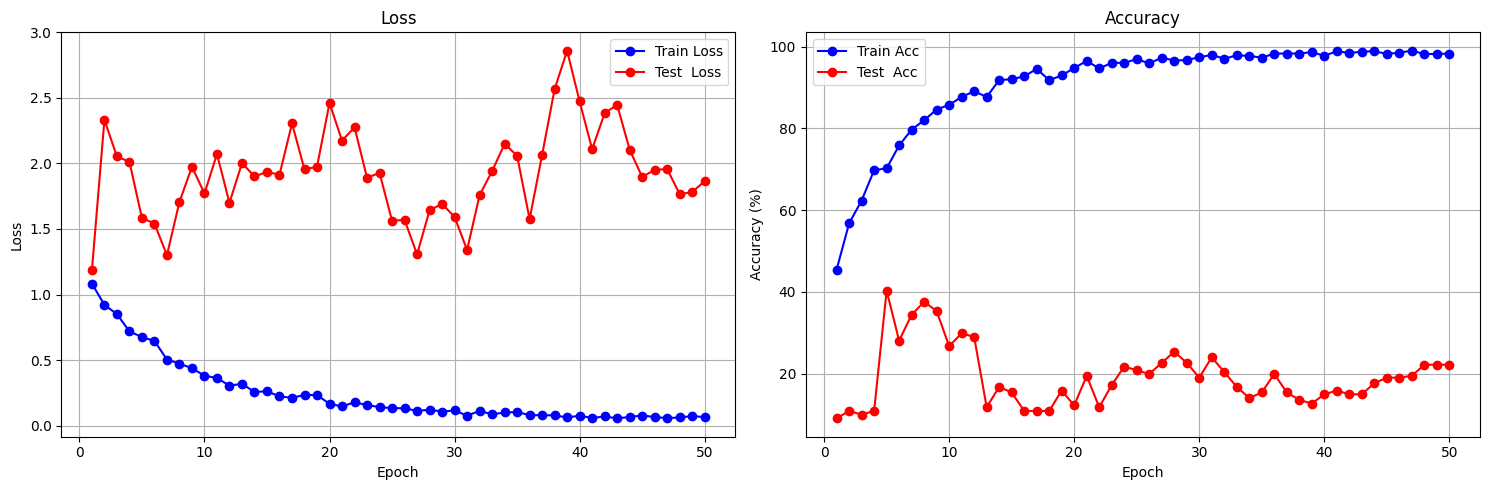

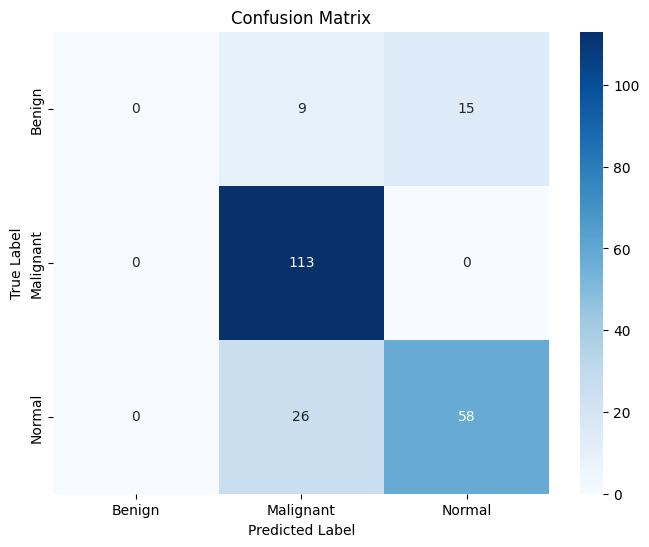

In [1]:
#!/usr/bin/env python3
"""
Complete Training and Testing Script for Lung Cancer Classification
Using Concatenated CNN Attention Model

Fixes applied:
1. Sequential per-class split     (no data leakage)
2. Capped class weights           (balanced, not overcorrected)
3. Gradient clipping               (no loss spikes)
4. Lower LR + CosineAnnealing     (stable convergence)
5. EMA weights                     (smooth evaluation)
"""

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import time
import json
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")


# ─────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────
class LungCancerDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir     = data_dir
        self.transform    = transform
        self.classes      = ['Bengin cases', 'Malignant cases', 'Normal cases']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                files = sorted([
                    f for f in os.listdir(class_dir)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm'))
                ])
                for img_file in files:
                    self.images.append(os.path.join(class_dir, img_file))
                    self.labels.append(self.class_to_idx[class_name])

        names = ['Benign', 'Malignant', 'Normal']
        logger.info("Dataset loaded (sorted):")
        for idx, name in enumerate(names):
            logger.info(f"  {name:<12}: {self.labels.count(idx)} slices")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ─────────────────────────────────────────────
# Transform Subset Wrapper
# ─────────────────────────────────────────────
class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ─────────────────────────────────────────────
# EMA
# ─────────────────────────────────────────────
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = (
                    self.decay * self.shadow[name]
                    + (1.0 - self.decay) * param.data
                )

    def apply_shadow(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data        = self.shadow[name]

    def restore(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]
        self.backup = {}


# ─────────────────────────────────────────────
# Model Components
# ─────────────────────────────────────────────
class CNNModel1(nn.Module):
    def __init__(self):
        super(CNNModel1, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(256)

        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = torch.relu(self.bn5(self.conv5(x)))
        x = self.global_max_pool(x)
        return x.view(x.size(0), -1)


class CNNModel2(nn.Module):
    def __init__(self):
        super(CNNModel2, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.global_max_pool = nn.AdaptiveMaxPool2d((1, 1))

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.global_max_pool(x)
        return x.view(x.size(0), -1)


class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super(MultiHeadAttentionBlock, self).__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, attn_weights = self.multihead_attn(x, x, x)
        x = self.layer_norm(x + self.dropout(attn_output))
        return x, attn_weights


class MLPBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=3, dropout=0.1):
        super(MLPBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.batch_norm1     = nn.BatchNorm1d(input_dim)
        self.dense1          = nn.Linear(input_dim, hidden_dim)
        self.batch_norm2     = nn.BatchNorm1d(hidden_dim)
        self.dense2          = nn.Linear(hidden_dim, num_classes)
        self.dropout         = nn.Dropout(dropout)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.batch_norm1(x)
        x = torch.nn.functional.gelu(self.dense1(x))
        x = self.dropout(x)
        x = self.batch_norm2(x)
        return self.dense2(x)


class ConcatenatedCNNAttentionModel(nn.Module):
    def __init__(self, num_classes=3, num_heads=4, hidden_dim=256, dropout=0.1):
        super(ConcatenatedCNNAttentionModel, self).__init__()
        self.cnn_model1 = CNNModel1()
        self.cnn_model2 = CNNModel2()

        self.concat_dim         = 256 + 32
        self.seq_length         = 8
        self.feature_projection = nn.Linear(
            self.concat_dim, self.seq_length * self.concat_dim
        )
        self.mha_layer1 = MultiHeadAttentionBlock(self.concat_dim, num_heads, dropout)
        self.mha_layer2 = MultiHeadAttentionBlock(self.concat_dim, num_heads, dropout)
        self.mlp_block  = MLPBlock(self.concat_dim, hidden_dim, num_classes, dropout)

    def forward(self, x):
        f1     = self.cnn_model1(x)
        f2     = self.cnn_model2(x)
        concat = torch.cat([f1, f2], dim=1)
        proj   = self.feature_projection(concat)
        seq    = proj.view(proj.size(0), self.seq_length, self.concat_dim)
        out, _ = self.mha_layer1(seq)
        out, _ = self.mha_layer2(out)
        return self.mlp_block(out)


# ─────────────────────────────────────────────
# Transforms
# ─────────────────────────────────────────────
def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    return train_transform, test_transform


# ─────────────────────────────────────────────
# Capped class weights
# ─────────────────────────────────────────────
def compute_class_weights(data_dir, device, max_weight=3.0):
    """
    weight = total / (num_classes * count)
    then CAPPED at max_weight to prevent overcorrection.

    Previous runs:
      uncapped Benign weight ≈ 8-9  → model only predicted Benign
      capped at 3.0               → gentle push, no collapse
    """
    dataset     = LungCancerDataset(data_dir, transform=None)
    labels      = dataset.labels
    total       = len(labels)
    num_classes = 3
    names       = ['Benign', 'Malignant', 'Normal']

    weights = []
    logger.info(f"Class weights (capped at {max_weight}):")
    for cls_idx, name in enumerate(names):
        count      = labels.count(cls_idx)
        raw_weight = total / (num_classes * count)
        capped     = min(raw_weight, max_weight)
        weights.append(capped)
        logger.info(
            f"  {name:<12}  count={count:>4}  "
            f"raw={raw_weight:.4f}  capped={capped:.4f}"
        )

    return torch.tensor(weights, dtype=torch.float).to(device)


# ─────────────────────────────────────────────
# Data Loaders — sequential split, normal shuffle
# ─────────────────────────────────────────────
def create_data_loaders(data_dir, batch_size=32, train_split=0.8, num_workers=4):
    """
    Sequential per-class split + normal shuffle (no weighted sampler).
    """
    train_transform, test_transform = get_transforms()

    full_dataset = LungCancerDataset(data_dir, transform=None)
    labels       = full_dataset.labels
    n            = len(full_dataset)
    class_names  = ['Benign', 'Malignant', 'Normal']

    train_indices = []
    test_indices  = []

    logger.info("Sequential per-class split:")
    for cls_idx in range(len(class_names)):
        cls_indices = [i for i in range(n) if labels[i] == cls_idx]
        split_at    = int(len(cls_indices) * train_split)

        train_indices.extend(cls_indices[:split_at])
        test_indices.extend(cls_indices[split_at:])

        logger.info(
            f"  {class_names[cls_idx]:<12}  "
            f"total={len(cls_indices):>4}  "
            f"train={split_at:>4}  "
            f"test={len(cls_indices) - split_at:>4}"
        )

    train_dataset = TransformSubset(
        Subset(full_dataset, train_indices), train_transform
    )
    test_dataset = TransformSubset(
        Subset(full_dataset, test_indices), test_transform
    )

    logger.info(f"Total train: {len(train_dataset)}")
    logger.info(f"Total test : {len(test_dataset)}")

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, test_loader


# ─────────────────────────────────────────────
# Train one epoch
# ─────────────────────────────────────────────
def train_epoch(model, train_loader, criterion, optimizer, device,
                ema=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    pbar = tqdm(train_loader, desc="Training")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()

        # gradient clipping — prevents loss spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        if ema is not None:
            ema.update(model)

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += targets.size(0)
        correct      += predicted.eq(targets).sum().item()

        pbar.set_postfix({
            'Loss': f"{running_loss / (batch_idx + 1):.4f}",
            'Acc' : f"{100. * correct / total:.2f}%"
        })

    return running_loss / len(train_loader), 100. * correct / total


# ─────────────────────────────────────────────
# Evaluate
# ─────────────────────────────────────────────
def test_model(model, test_loader, criterion, device, ema=None):
    if ema is not None:
        ema.apply_shadow(model)

    model.eval()
    test_loss       = 0.0
    correct         = 0
    total           = 0
    all_targets     = []
    all_predictions = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)

            test_loss   += loss.item()
            _, predicted = outputs.max(1)
            total       += targets.size(0)
            correct     += predicted.eq(targets).sum().item()

            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

            pbar.set_postfix({
                'Loss': f"{test_loss / len(pbar):.4f}",
                'Acc' : f"{100. * correct / total:.2f}%"
            })

    if ema is not None:
        ema.restore(model)

    return (
        test_loss / len(test_loader),
        100. * correct / total,
        all_targets,
        all_predictions
    )


# ─────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────
def plot_confusion_matrix(targets, predictions, class_names, save_path=None):
    cm = confusion_matrix(targets, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_training_curves(train_losses, train_accs,
                         test_losses, test_accs, save_path=None):
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(epochs, train_losses, 'bo-', label='Train Loss')
    ax1.plot(epochs, test_losses,  'ro-', label='Test  Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_accs, 'bo-', label='Train Acc')
    ax2.plot(epochs, test_accs,  'ro-', label='Test  Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ─────────────────────────────────────────────
# Model save / load
# ─────────────────────────────────────────────
def save_model(model, optimizer, epoch, loss, accuracy, filepath):
    torch.save({
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss'                : loss,
        'accuracy'            : accuracy,
    }, filepath)
    logger.info(f"Model saved → {filepath}")


def load_model(model, optimizer, filepath):
    ckpt = torch.load(filepath, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    logger.info(
        f"Model loaded ← {filepath}  "
        f"(Epoch {ckpt['epoch']}, Acc {ckpt['accuracy']:.2f}%)"
    )
    return ckpt['epoch'], ckpt['loss'], ckpt['accuracy']


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
def main():
    config = {
        'data_dir'      : '/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset',
        'batch_size'    : 32,
        'num_epochs'    : 50,
        'learning_rate' : 0.00005,    # lower LR for stability
        'weight_decay'  : 1e-4,
        'num_workers'   : 4,
        'save_dir'      : 'checkpoints',
        'results_dir'   : 'results',
        'ema_decay'     : 0.999,
        'max_grad_norm' : 1.0,       # gradient clipping
        'max_weight'    : 3.0,       # cap on class weights
    }

    class_names = ['Benign', 'Malignant', 'Normal']

    os.makedirs(config['save_dir'],    exist_ok=True)
    os.makedirs(config['results_dir'], exist_ok=True)

    # ── Data ──────────────────────────────────
    logger.info("Creating data loaders...")
    train_loader, test_loader = create_data_loaders(
        config['data_dir'],
        batch_size=config['batch_size'],
        num_workers=config['num_workers']
    )

    # ── Model ─────────────────────────────────
    logger.info("Creating model...")
    model = ConcatenatedCNNAttentionModel(num_classes=3).to(device)

    # Capped class weights — gentle Benign boost, no overcorrection
    class_weights = compute_class_weights(
        config['data_dir'], device,
        max_weight=config['max_weight']
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    # Cosine annealing — smooth LR decay, no sudden drops
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config['num_epochs'],
        eta_min=1e-6
    )

    # EMA
    ema = EMA(model, decay=config['ema_decay'])

    # ── Tracking ──────────────────────────────
    train_losses, train_accs = [], []
    test_losses,  test_accs  = [], []
    best_acc = 0.0

    logger.info(f"Starting training for {config['num_epochs']} epochs...")

    # ── Training Loop ─────────────────────────
    for epoch in range(1, config['num_epochs'] + 1):
        start      = time.time()
        current_lr = optimizer.param_groups[0]['lr']
        logger.info(
            f"\nEpoch {epoch}/{config['num_epochs']}  |  LR: {current_lr:.6f}"
        )

        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device,
            ema=ema, max_grad_norm=config['max_grad_norm']
        )
        test_loss, test_acc, targets, predictions = test_model(
            model, test_loader, criterion, device, ema=ema
        )

        scheduler.step()

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        logger.info(f"Train → Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")
        logger.info(f"Test  → Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%")
        logger.info(f"Time  → {time.time() - start:.2f}s")

        if test_acc > best_acc:
            best_acc = test_acc
            save_model(
                model, optimizer, epoch, test_loss, test_acc,
                os.path.join(config['save_dir'], 'best_model.pth')
            )
            logger.info(f"★ New best: {best_acc:.2f}%")

    # ── Final Evaluation ──────────────────────
    logger.info("\n" + "=" * 55)
    logger.info("FINAL EVALUATION")
    logger.info("=" * 55)

    load_model(model, optimizer, os.path.join(config['save_dir'], 'best_model.pth'))

    _, test_acc, final_targets, final_predictions = test_model(
        model, test_loader, criterion, device, ema=ema
    )

    # ── Classification Report ─────────────────
    print("\n" + "=" * 55)
    print("CLASSIFICATION REPORT")
    print("=" * 55)
    print(classification_report(
        final_targets,
        final_predictions,
        target_names=class_names,
        digits=4
    ))

    # ── Plots ─────────────────────────────────
    plot_training_curves(
        train_losses, train_accs, test_losses, test_accs,
        save_path=os.path.join(config['results_dir'], 'training_curves.png')
    )
    plot_confusion_matrix(
        final_targets, final_predictions, class_names,
        save_path=os.path.join(config['results_dir'], 'confusion_matrix.png')
    )

    # ── Save Results ──────────────────────────
    results = {
        'best_accuracy'      : best_acc,
        'final_test_accuracy': test_acc,
        'train_losses'       : train_losses,
        'train_accuracies'   : train_accs,
        'test_losses'        : test_losses,
        'test_accuracies'    : test_accs,
        'config'             : config,
    }
    with open(os.path.join(config['results_dir'], 'results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    logger.info(f"Done!  Best accuracy: {best_acc:.2f}%")


if __name__ == "__main__":
    main()